# Airbnb Mexico City — Price Analysis
## Notebook 02: Data Cleaning & Feature Engineering

**Previous step:** `01_data_loading.ipynb` — dataset loaded, 27,051 rows × 18 columns  
**This notebook:** Fix all quality issues identified in Notebook 01, engineer new features, and produce a clean dataset ready for statistical analysis.

---

### Issues to resolve (from Notebook 01)

| Column | Issue | Strategy |
|---|---|---|
| `price` | 12.9% missing, stored as string | Drop nulls, parse to float |
| `review_scores_rating` | 12.6% missing (new listings) | Keep rows, add `has_reviews` flag |
| `host_is_superhost` | 6.2% missing (inactive hosts) | Drop rows |
| `bedrooms` | 3.6% missing | Impute with median by `room_type` |
| `bathrooms_text` | 0.1% missing | Extract numeric value, impute median |
| `price_usd` | Extreme outliers | Remove using IQR rule |
| `minimum_nights` | Values > 30 are not STR | Cap or remove |
| `amenities` | JSON-like string | Parse and count |
| `host_is_superhost` | String `'t'`/`'f'` | Convert to boolean |

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
import os
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

os.makedirs('data/processed', exist_ok=True)
os.makedirs('reports/figures', exist_ok=True)

# Load output from Notebook 01
df = pd.read_csv('data/processed/listings_core.csv', low_memory=False)

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded: 27,051 rows × 18 columns


## 2. Helper: Cleaning Tracker

We track row counts after each step to make the data loss transparent and explainable — a good practice in any professional analysis.

In [2]:
cleaning_log = []

def log_step(label: str, df: pd.DataFrame) -> None:
    """Record the row count after each cleaning step."""
    cleaning_log.append({'step': label, 'rows': len(df)})
    print(f'  [{label}] → {len(df):,} rows remaining')

log_step('Raw input', df)

  [Raw input] → 27,051 rows remaining


## 3. Step-by-Step Cleaning

### 3.1 Price — parse string and drop nulls

**Why drop instead of impute?** Price is our target variable. Imputing it would introduce circular bias into the model — we'd be predicting a value we invented.

In [3]:
# Parse price string → float (handles '$1,200.00' format)
df['price_usd'] = (
    df['price']
    .str.replace(r'[$,]', '', regex=True)
    .astype(float)
)

# Drop rows where price is null or zero
df = df[df['price_usd'].notna() & (df['price_usd'] > 0)].copy()
log_step('Drop null/zero prices', df)

  [Drop null/zero prices] → 23,567 rows remaining


### 3.2 Price outliers — IQR filtering

**Why IQR and not z-score?** Because the price distribution is right-skewed, z-score would be biased toward the upper tail. IQR is robust to skew.

> This is the Spiegelhalter principle in practice: the right summary statistic depends on the shape of the distribution.

In [4]:
Q1 = df['price_usd'].quantile(0.25)
Q3 = df['price_usd'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

print(f'IQR fence: ${lower_bound:.0f} — ${upper_bound:.0f}')
print(f'Listings outside bounds: {((df["price_usd"] < lower_bound) | (df["price_usd"] > upper_bound)).sum():,}')

df = df[
    (df['price_usd'] >= lower_bound) &
    (df['price_usd'] <= upper_bound)
].copy()

log_step('Remove price outliers (IQR)', df)

IQR fence: $0 — $3063
Listings outside bounds: 1,768
  [Remove price outliers (IQR)] → 21,799 rows remaining


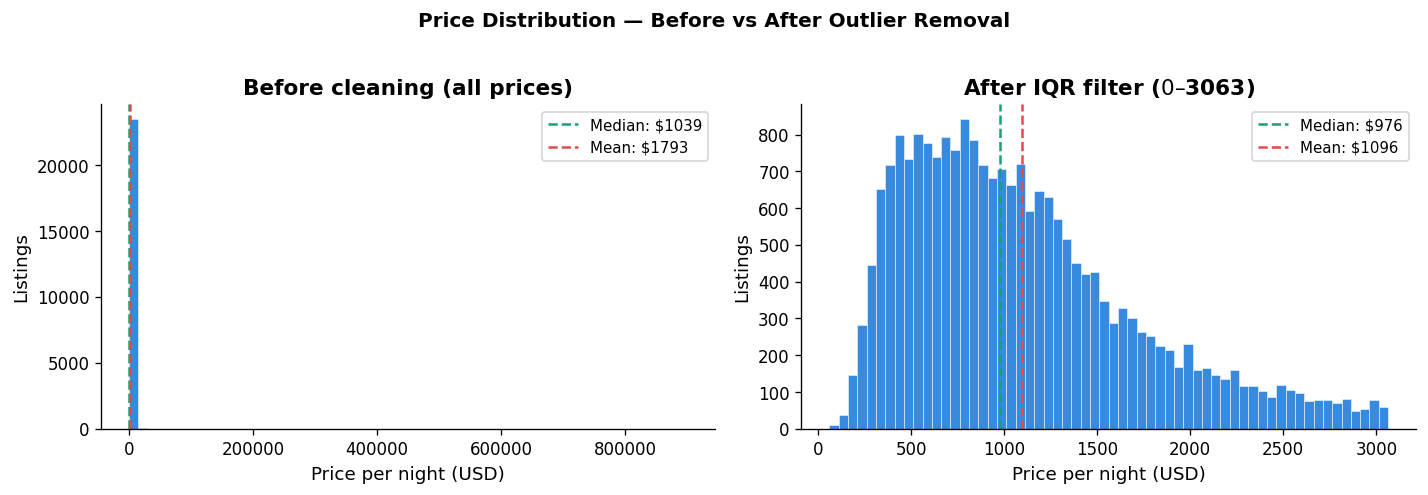

In [5]:
# Visualise price distribution before vs after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, title in zip(
    axes,
    [pd.read_csv('data/processed/listings_core.csv')['price']
         .str.replace(r'[$,]', '', regex=True).astype(float).dropna(),
     df['price_usd']],
    ['Before cleaning (all prices)', f'After IQR filter (${lower_bound:.0f}–${upper_bound:.0f})']
):
    ax.hist(data, bins=60, color='#378ADD', edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='#1D9E75', linestyle='--', linewidth=1.5,
               label=f'Median: ${data.median():.0f}')
    ax.axvline(data.mean(), color='#E24B4A', linestyle='--', linewidth=1.5,
               label=f'Mean: ${data.mean():.0f}')
    ax.set_xlabel('Price per night (USD)')
    ax.set_ylabel('Listings')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Price Distribution — Before vs After Outlier Removal', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/price_before_after_cleaning.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.3 Inactive hosts — drop missing `host_is_superhost`

Hosts with `NaN` in this field are either suspended or have never completed their profile. They represent a different population from active hosts and would add noise to the model.

In [6]:
df = df[df['host_is_superhost'].notna()].copy()

# Convert 't'/'f' strings to boolean
df['host_is_superhost'] = df['host_is_superhost'].map({'t': True, 'f': False})

print(f'Superhost breakdown:')
print(df['host_is_superhost'].value_counts())
log_step('Drop inactive hosts', df)

Superhost breakdown:
host_is_superhost
False    11964
True      8472
Name: count, dtype: int64
  [Drop inactive hosts] → 20,436 rows remaining


### 3.4 `review_scores_rating` — flag missing instead of dropping

A missing rating means the listing has no reviews yet — likely a new listing. This is **informative, not random**. We keep the rows and create a binary flag. In the model, we can test whether 'no reviews' itself affects price.

In [7]:
df['has_reviews'] = df['review_scores_rating'].notna().astype(int)

# Impute missing rating with median (only used in model, flag preserves the signal)
median_rating = df['review_scores_rating'].median()
df['review_scores_rating'] = df['review_scores_rating'].fillna(median_rating)

print(f'Listings with reviews: {df["has_reviews"].sum():,} ({df["has_reviews"].mean()*100:.1f}%)')
print(f'Median rating used for imputation: {median_rating}')

Listings with reviews: 18,419 (90.1%)
Median rating used for imputation: 4.84


### 3.5 `bedrooms` — impute with median by room type

A private room typically has 1 bedroom. An entire home might have 2 or 3. Imputing by group is more accurate than a global median.

In [8]:
bedroom_medians = df.groupby('room_type')['bedrooms'].median()
print('Median bedrooms by room type:')
print(bedroom_medians)

df['bedrooms'] = df.groupby('room_type')['bedrooms'].transform(
    lambda x: x.fillna(x.median())
)

# Ensure at least 0 (some studios legitimately have 0 bedrooms)
df['bedrooms'] = df['bedrooms'].clip(lower=0)

print(f'\nRemaining null bedrooms: {df["bedrooms"].isna().sum()}')

Median bedrooms by room type:
room_type
Entire home/apt    1.0
Hotel room         1.0
Private room       1.0
Shared room        1.0
Name: bedrooms, dtype: float64

Remaining null bedrooms: 0


### 3.6 `bathrooms_text` — extract numeric value

In [9]:
# Examples of raw values in this column
print('Raw bathroom examples:')
print(df['bathrooms_text'].dropna().unique()[:15])

Raw bathroom examples:
['1 bath' '1 private bath' '1.5 baths' '2 baths' '1.5 shared baths'
 '5.5 baths' '2.5 baths' '1 shared bath' '2 shared baths' '3 baths'
 'Half-bath' '5 baths' '3 shared baths' '4 baths' '0 baths']


In [10]:
def parse_bathrooms(text: str) -> float:
    """Extract numeric value from strings like '1.5 baths', 'Shared half-bath', etc."""
    if pd.isna(text):
        return np.nan
    text = str(text).lower()
    if 'half' in text:
        return 0.5
    match = re.search(r'(\d+\.?\d*)', text)
    return float(match.group(1)) if match else np.nan

df['bathrooms'] = df['bathrooms_text'].apply(parse_bathrooms)

# Impute remaining nulls with global median
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bathrooms'] = df['bathrooms'].clip(lower=0)

print('Bathrooms value counts (top 10):')
print(df['bathrooms'].value_counts().head(10))

Bathrooms value counts (top 10):
bathrooms
1.0    13986
2.0     3569
1.5     1390
2.5      580
3.0      369
0.0      105
3.5       96
4.0       89
0.5       88
5.0       65
Name: count, dtype: int64


### 3.7 `minimum_nights` — remove long-term rentals

Listings requiring 30+ minimum nights are not short-term rentals — they compete in a different market with a different pricing logic. Keeping them would add noise to our analysis.

In [11]:
print(f'Listings with minimum_nights > 30: {(df["minimum_nights"] > 30).sum():,}')
print(f'Listings with minimum_nights > 7:  {(df["minimum_nights"] > 7).sum():,}')

df = df[df['minimum_nights'] <= 30].copy()
log_step('Remove long-term rentals (min_nights > 30)', df)

Listings with minimum_nights > 30: 107
Listings with minimum_nights > 7:  910
  [Remove long-term rentals (min_nights > 30)] → 20,329 rows remaining


### 3.8 `amenities` — count as a numeric feature

The raw column contains a list like `["Wifi", "Kitchen", "Air conditioning"]`. Rather than one-hot encoding hundreds of amenities, we use the **count** as a proxy for listing quality — a standard and effective approach.

In [12]:
def count_amenities(amenities_str: str) -> int:
    """Count the number of amenities from a JSON-like string."""
    if pd.isna(amenities_str):
        return 0
    try:
        return len(ast.literal_eval(amenities_str))
    except (ValueError, SyntaxError):
        return len(str(amenities_str).split(','))

df['amenities_count'] = df['amenities'].apply(count_amenities)

print('Amenities count stats:')
print(df['amenities_count'].describe().round(1))

Amenities count stats:
count    20329.0
mean        31.9
std         15.2
min          0.0
25%         21.0
50%         33.0
75%         43.0
max        102.0
Name: amenities_count, dtype: float64


## 4. Feature Engineering

New variables derived from existing ones that may better capture the relationship with price.

In [13]:
# Log-transformed price — our actual target variable for regression
# Reason: linear regression assumes normally distributed residuals.
# log(price) is approximately normal, while price itself is right-skewed.
df['log_price'] = np.log1p(df['price_usd'])

# Price per person (normalises for group vs solo listings)
df['price_per_person'] = df['price_usd'] / df['accommodates'].clip(lower=1)

# Host experience: is this a multi-listing host (professional) or individual?
df['is_professional_host'] = (df['host_listings_count'] > 1).astype(int)

# Availability ratio: how available is the listing? (0 = always booked, 1 = always free)
df['availability_ratio'] = df['availability_365'] / 365

# Room type as ordered category (useful for some visualisations)
room_order = ['Shared room', 'Hotel room', 'Private room', 'Entire home/apt']
df['room_type_cat'] = pd.Categorical(df['room_type'], categories=room_order, ordered=True)

print('New features created:')
new_features = ['log_price', 'price_per_person', 'is_professional_host',
                'availability_ratio', 'room_type_cat', 'amenities_count',
                'has_reviews', 'bathrooms']
print(df[new_features].describe().round(2))

New features created:
       log_price  price_per_person  is_professional_host  availability_ratio  \
count   20329.00          20329.00              20329.00            20329.00   
mean        6.83            400.30                  0.75                0.70   
std         0.60            234.39                  0.43                0.29   
min         4.13             14.06                  0.00                0.00   
25%         6.41            241.25                  0.00                0.49   
50%         6.88            345.50                  1.00                0.78   
75%         7.26            496.00                  1.00                0.95   
max         8.03           3000.00                  1.00                1.00   

       amenities_count  has_reviews  bathrooms  
count         20329.00      20329.0   20329.00  
mean             31.92          0.9       1.34  
std              15.20          0.3       0.71  
min               0.00          0.0       0.00  
25%         

## 5. Final Dataset Validation

In [14]:
# Columns to keep in clean dataset
FINAL_COLS = [
    'id',
    'neighbourhood_cleansed',
    'latitude', 'longitude',
    'room_type',
    'accommodates',
    'bedrooms',
    'bathrooms',
    'amenities_count',
    'price_usd',
    'log_price',
    'price_per_person',
    'minimum_nights',
    'number_of_reviews',
    'has_reviews',
    'review_scores_rating',
    'host_is_superhost',
    'is_professional_host',
    'host_listings_count',
    'availability_365',
    'availability_ratio',
]

df_clean = df[FINAL_COLS].copy()

print('=== Clean Dataset Summary ===')
print(f'Rows:    {df_clean.shape[0]:,}')
print(f'Columns: {df_clean.shape[1]}')
print(f'\nRemaining nulls:')
nulls = df_clean.isna().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else '  None — dataset is complete.')

=== Clean Dataset Summary ===
Rows:    20,329
Columns: 21

Remaining nulls:
host_listings_count    1
dtype: int64


### Cleaning waterfall — how many rows were removed and why

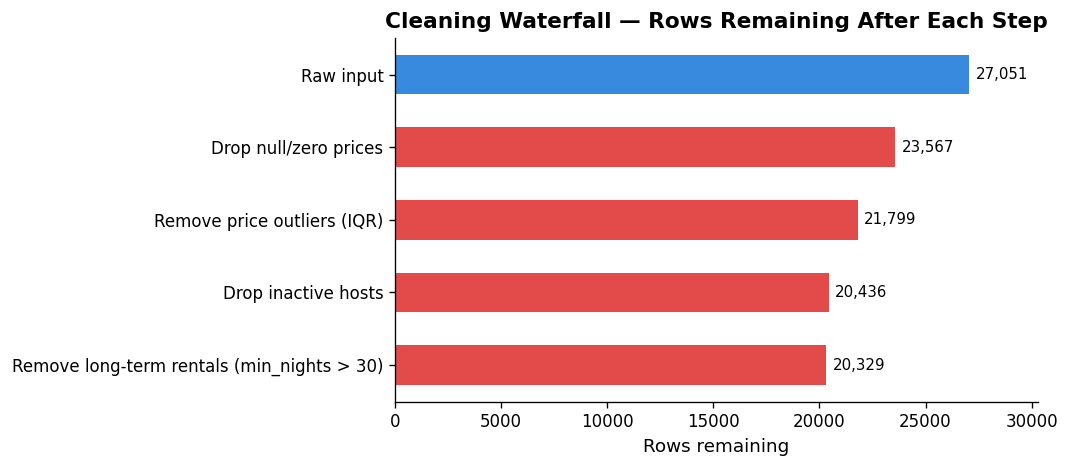


Detailed log:
                                      step  rows  rows_removed  pct_removed
                                 Raw input 27051           NaN          NaN
                     Drop null/zero prices 23567        3484.0         12.9
               Remove price outliers (IQR) 21799        1768.0          6.5
                       Drop inactive hosts 20436        1363.0          5.0
Remove long-term rentals (min_nights > 30) 20329         107.0          0.4


In [15]:
log_df = pd.DataFrame(cleaning_log)
log_df['rows_removed'] = log_df['rows'].shift(1) - log_df['rows']
log_df['pct_removed'] = (log_df['rows_removed'] / log_df['rows'].iloc[0] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#378ADD' if i == 0 else '#E24B4A' for i in range(len(log_df))]
bars = ax.barh(log_df['step'][::-1], log_df['rows'][::-1], color=colors[::-1], height=0.55)
ax.bar_label(bars, labels=[f'{v:,}' for v in log_df['rows'][::-1]], padding=4, fontsize=9)
ax.set_xlabel('Rows remaining')
ax.set_title('Cleaning Waterfall — Rows Remaining After Each Step')
ax.set_xlim(0, log_df['rows'].max() * 1.12)
plt.tight_layout()
plt.savefig('reports/figures/cleaning_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nDetailed log:')
print(log_df.to_string(index=False))

### Distribution of the target variable — before and after log transform

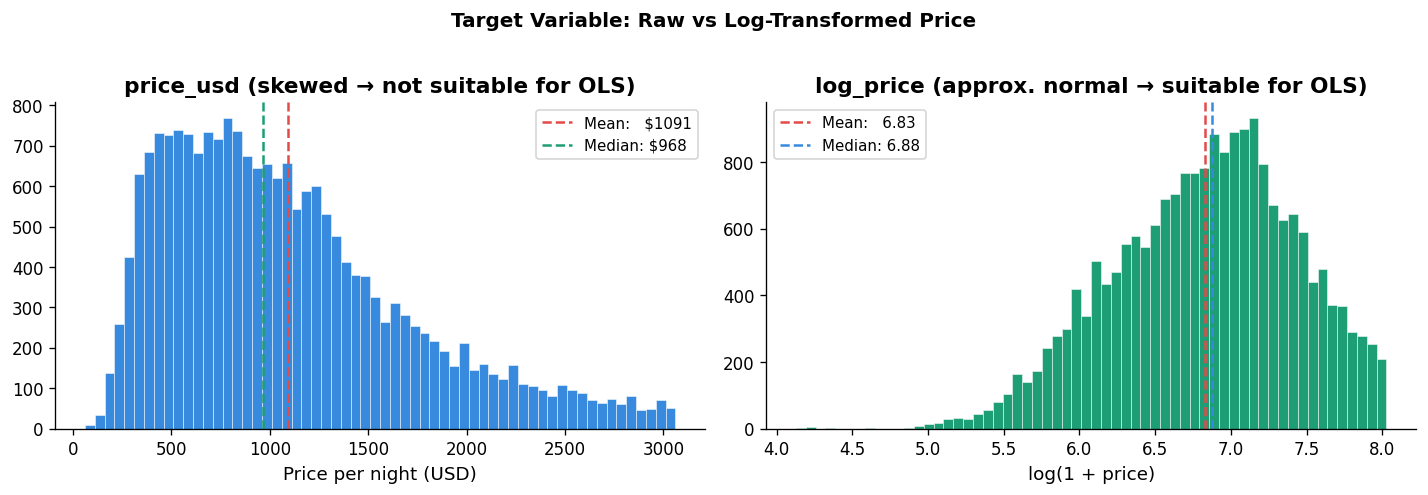

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw price
axes[0].hist(df_clean['price_usd'], bins=60, color='#378ADD', edgecolor='white', linewidth=0.3)
axes[0].axvline(df_clean['price_usd'].mean(),   color='#E24B4A', linestyle='--', lw=1.5,
                label=f'Mean:   ${df_clean["price_usd"].mean():.0f}')
axes[0].axvline(df_clean['price_usd'].median(), color='#1D9E75', linestyle='--', lw=1.5,
                label=f'Median: ${df_clean["price_usd"].median():.0f}')
axes[0].set_title('price_usd (skewed → not suitable for OLS)')
axes[0].set_xlabel('Price per night (USD)')
axes[0].legend(fontsize=9)

# Log price
axes[1].hist(df_clean['log_price'], bins=60, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].axvline(df_clean['log_price'].mean(),   color='#E24B4A', linestyle='--', lw=1.5,
                label=f'Mean:   {df_clean["log_price"].mean():.2f}')
axes[1].axvline(df_clean['log_price'].median(), color='#378ADD', linestyle='--', lw=1.5,
                label=f'Median: {df_clean["log_price"].median():.2f}')
axes[1].set_title('log_price (approx. normal → suitable for OLS)')
axes[1].set_xlabel('log(1 + price)')
axes[1].legend(fontsize=9)

plt.suptitle('Target Variable: Raw vs Log-Transformed Price', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/target_log_transform.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Save Clean Dataset

In [17]:
df_clean.to_csv('data/processed/listings_clean.csv', index=False)

print('Saved: data/processed/listings_clean.csv')
print(f'Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'Rows retained: {df_clean.shape[0] / 27051 * 100:.1f}% of original dataset')
print('\nReady for Notebook 03: EDA & Statistical Analysis')

Saved: data/processed/listings_clean.csv
Final shape: 20,329 rows × 21 columns
Rows retained: 75.2% of original dataset

Ready for Notebook 03: EDA & Statistical Analysis


---

## Key Decisions & Rationale

| Decision | Reason |
|---|---|
| Drop null prices (not impute) | Price is our target — inventing values would bias the model |
| IQR for outliers (not z-score) | Right-skewed distribution makes z-score unreliable |
| Flag missing ratings (not drop) | Missingness is informative — new listings have no reviews yet |
| Impute bedrooms by room type group | Group median is more accurate than global median |
| Remove listings with min_nights > 30 | Different market, different pricing logic |
| Use `log(price)` as target | Makes the distribution approximately normal — required for OLS assumptions |
| Count amenities instead of one-hot | Avoids dimensionality explosion; count is a valid quality proxy |

**Next step →** `03_eda_statistics.ipynb`